<a href="https://colab.research.google.com/github/zackives/upenn-cis5450-hw/blob/main/ARIMA_SARIMA_more.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Timeseries

Portions based on https://medium.com/@tirthamutha/time-series-forecasting-using-sarima-in-python-8b75cd3366f2 and https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html#ARIMA-Example-2:-Arima-with-additive-seasonal-effects.

In [ ]:
!wget https://storage.googleapis.com/penn-cis5450/DailyDelhiClimate.csv

--2024-08-01 13:39:16--  https://storage.googleapis.com/penn-cis5450/DailyDelhiClimate.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.142.207, 173.194.202.207, 173.194.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.142.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85248 (83K) [text/csv]
Saving to: ‘DailyDelhiClimate.csv.1’

DailyDelhiClimate.c 100%[===================>]  83.25K  --.-KB/s    in 0.001s  

2024-08-01 13:39:16 (90.4 MB/s) - ‘DailyDelhiClimate.csv.1’ saved [85248/85248]



Rather than the daily Australian dataset, we'll use a Kaggle dataset about daily temperatures in Delhi.  We know temperatures should be correlated day-to-day and season-to-season -- with a 12 month gap between seasons.

https://www.kaggle.com/datasets/sukhmandeepsinghbrar/daily-delhi-climate

<Axes: xlabel='date'>

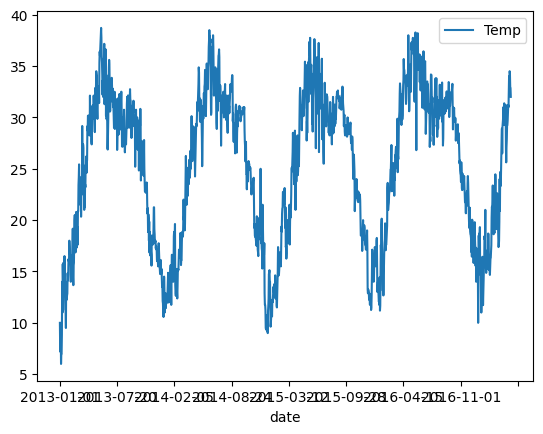

In [ ]:
import pandas as pd

temps = pd.read_csv('DailyDelhiClimate.csv', header=0, index_col=0)

temps = temps[['Temp']]
temps.plot()

Let's look at the correlation between the lags and the data (autocorrelation) for a good region (more than a year)...

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

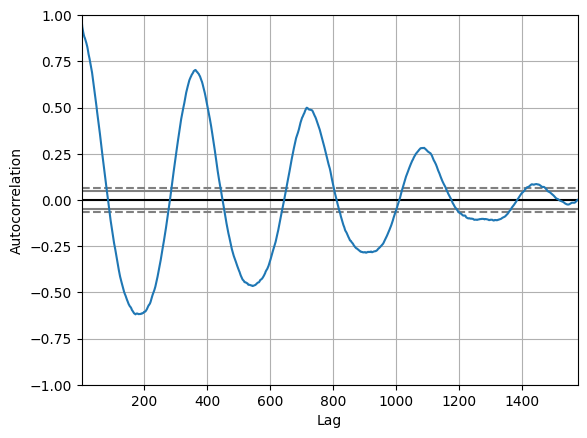

In [ ]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(temps['Temp'])

And more locally as well...

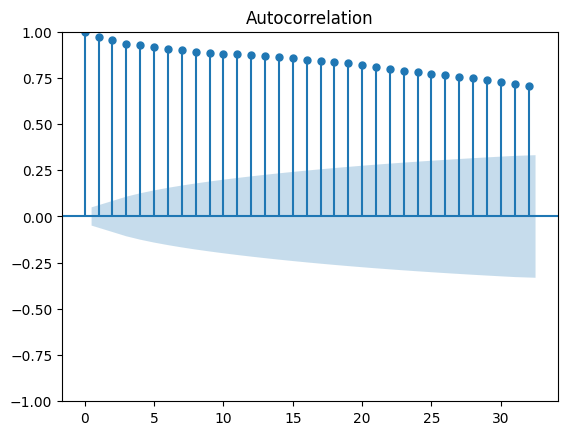

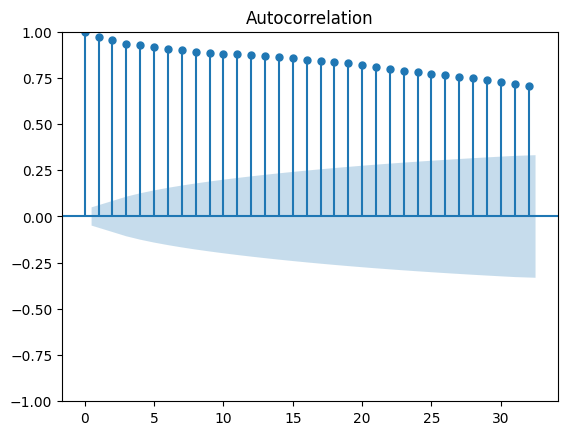

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(temps)

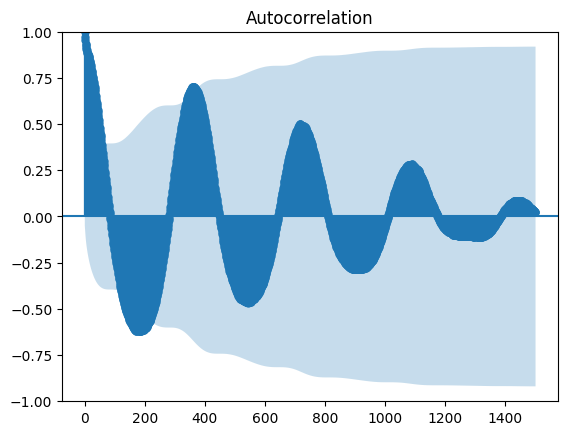

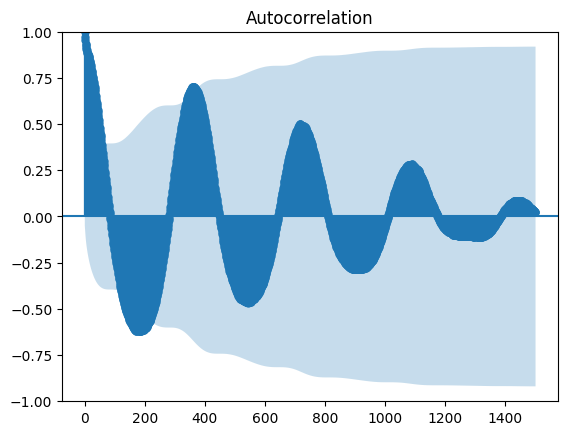

In [ ]:
plot_acf(temps, lags=1500)

Autocorrelation (as above) considers the correlation of the function's value with its distant previous values, indirectly considering all values in between. We can also look at *partial* autocorrelation, which is a direct correlation between the value and its past lag.

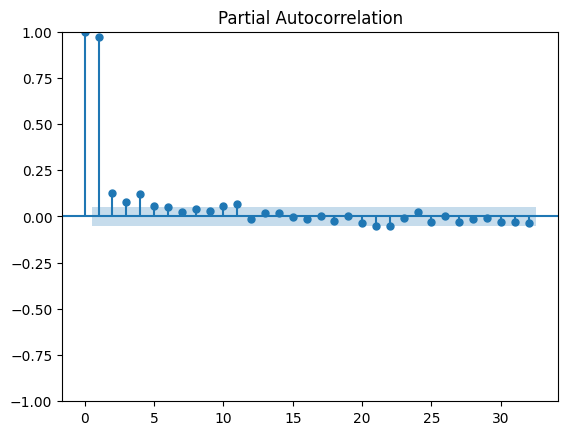

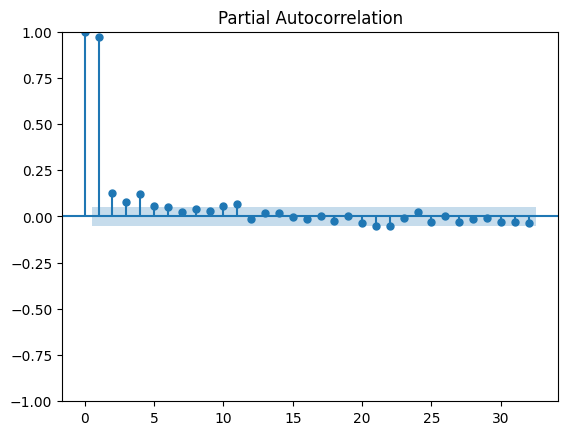

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(temps)

Here we can see that the 3rd lag, for instance, is less correlated than the 4th, 5th, etc.

## Takeaways So Far

We have both ARIMA (which follows *small, short-term seasonality within the lags*, as well as longer tremds) and SARIMA (which allows us to include a longer-term seasonal element).

The above plots let us understand how many lags make sense.  We can further fine-tune (p,d,q) for "local" and "seasonal" components with grid search -- but even basic values are likely to work well.

In [ ]:
!pip install pmdarima

In [ ]:
import pmdarima as pmd
model = pmd.auto_arima(temps['Temp'],start_p=1,start_q=1,test='adf',m=12,seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=5995.445, Time=26.22 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=6104.687, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=6067.988, Time=3.89 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=6056.265, Time=4.30 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=6102.796, Time=0.13 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=5996.594, Time=8.33 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=5996.566, Time=9.66 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=5996.702, Time=27.07 sec
 ARIMA(1,1,1)(1,0,2)[12] intercept   : AIC=5996.640, Time=21.94 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=5995.198, Time=2.08 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=6054.571, Time=1.09 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=6066.213, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=5997.066, Time=1.22 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=5997.088, Time=0.88 sec
 ARIMA(0,1,2)(0,

In [ ]:
import statsmodels.api as sm

sarima=sm.tsa.statespace.SARIMAX(temps,order=(1,1,1),seasonal_order=(1,0,1,12))
predicted=sarima.fit().predict();

# Let's compare against a model without the Seasonal component
sarima=sm.tsa.statespace.SARIMAX(temps,order=(1,1,1))
predicted2=sarima.fit().predict();

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


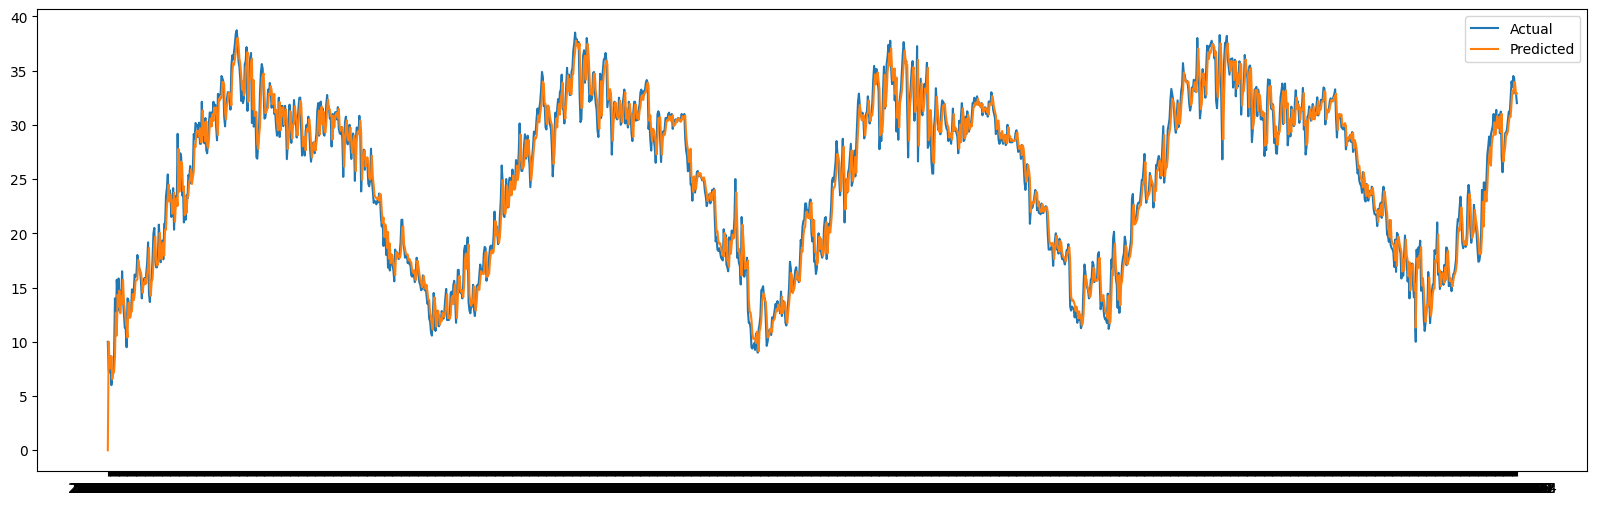

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))
plt.plot(temps['Temp'],label='Actual')
plt.plot(predicted,label='Predicted')
# plt.plot(predicted,label='Nonseasonal')

plt.legend()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

df = temps.copy()

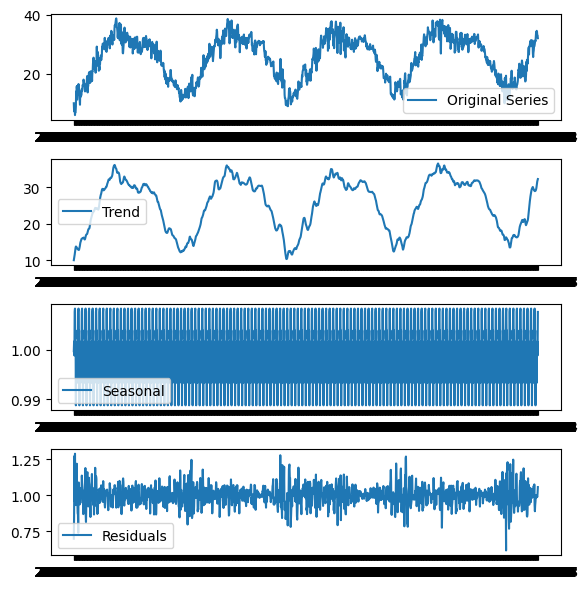

In [ ]:
result = seasonal_decompose(df['Temp'], model='multiplicative', period=12)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(4,6))

plt.subplot(4, 1, 1)
plt.plot(df['Temp'], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()
